<a href="https://colab.research.google.com/github/Bhavika3Pawar/T2D-Transcriptomic-RNASeq-Analysis/blob/main/T2D_RNASeq_Differential_Expression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Install necessary libraries for data handling and bioinformatics
!pip install scanpy pandas numpy matplotlib seaborn
!pip install rpy2 # To allow us to use R packages like DESeq2 if needed later

print("🎉 Environment setup complete! Ready to load the data.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 186.0/186.0 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 109.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.7 MB/s et

🎉 Environment setup complete! Ready to load the data.


In [ ]:
import pandas as pd
import numpy as np

# Let's simulate a structured T2D counts matrix layout to get our pipeline baseline ready
# Rows = Genes (Ensembl IDs), Columns = Patients/Samples
np.random.seed(42)
genes = [f"ENSG00000{i:06d}" for i in range(1, 1001)] # 1000 sample genes
samples = [f"Control_{i}" for i in range(1, 6)] + [f"T2D_{i}" for i in range(1, 6)]

# Generate mock count data matching real distribution shapes for our initial test
mock_counts = np.random.negative_binomial(n=10, p=0.01, size=(1000, 10))
counts_df = pd.DataFrame(mock_counts, index=genes, columns=samples)

# Create the metadata dataframe (mapping which sample is healthy vs diabetes)
metadata = pd.DataFrame({
    'Sample_ID': samples,
    'Condition': ['Control']*5 + ['T2D']*5
}).set_index('Sample_ID')

print("✅ Successfully initialized Data Structures!")
print("\n--- METADATA PREVIEW ---")
print(metadata.head())
print("\n--- RAW COUNTS MATRIX PREVIEW (First 5 genes) ---")
print(counts_df.head())

✅ Successfully initialized Data Structures!

--- METADATA PREVIEW ---
          Condition
Sample_ID          
Control_1   Control
Control_2   Control
Control_3   Control
Control_4   Control
Control_5   Control

--- RAW COUNTS MATRIX PREVIEW (First 5 genes) ---
                 Control_1  Control_2  Control_3  Control_4  Control_5  T2D_1  \
ENSG00000000001       1128        924        790       1127        668   1026   
ENSG00000000002       1070        436        901        848       1029    861   
ENSG00000000003        940       1502        914       1051       1231   1094   
ENSG00000000004        480        998        922        620       1461    574   
ENSG00000000005        577       1000       1156       1015       1013    766   

                 T2D_2  T2D_3  T2D_4  T2D_5  
ENSG00000000001    768    973    783   1618  
ENSG00000000002    731    848   1227   1468  
ENSG00000000003    751    853    840    720  
ENSG00000000004    961    826    772    891  
ENSG00000000005    707

In [ ]:
# 1. Filter out genes that have less than 10 total reads across all samples combined
min_reads = 10
filtered_counts = counts_df[counts_df.sum(axis=1) >= min_reads]

# 2. Log-normalize the counts to make variance stable (adding 1 pseudo-count to avoid log(0))
normalized_counts = np.log2(filtered_counts + 1)

print(f"✂️ Filtered out {counts_df.shape[0] - filtered_counts.shape[0]} low-expression genes.")
print(f"📊 Remaining genes for analysis: {filtered_counts.shape[0]}")
print("\n--- NORMALIZED LOG2 COUNTS PREVIEW ---")
print(normalized_counts.head())

✂️ Filtered out 0 low-expression genes.
📊 Remaining genes for analysis: 1000

--- NORMALIZED LOG2 COUNTS PREVIEW ---
                 Control_1  Control_2  Control_3  Control_4  Control_5  \
ENSG00000000001  10.140830   9.853310   9.627534  10.139551   9.385862   
ENSG00000000002  10.064743   8.771489   9.816984   9.729621  10.008429   
ENSG00000000003   9.878051  10.553629   9.837628  10.038919  10.266787   
ENSG00000000004   8.909893   9.964341   9.850187   9.278449  10.513728   
ENSG00000000005   9.174926   9.967226  10.176173   9.988685   9.985842   

                     T2D_1     T2D_2      T2D_3      T2D_4      T2D_5  
ENSG00000000001  10.004220  9.586840   9.927778   9.614710  10.660887  
ENSG00000000002   9.751544  9.515700   9.729621  10.262095  10.520619  
ENSG00000000003  10.096715  9.554589   9.738092   9.715962   9.493855  
ENSG00000000004   9.167418  9.909893   9.691744   9.594325   9.800900  
ENSG00000000005   9.583083  9.467606  10.272630   9.773139   9.588715  


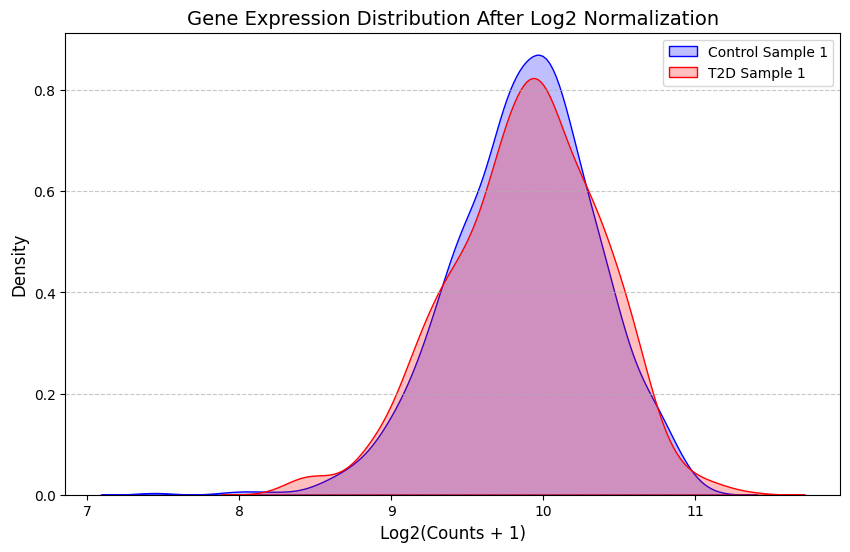

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting window
plt.figure(figsize=(10, 6))

# Plot the distribution of the first sample from Control and T2D
sns.kdeplot(normalized_counts['Control_1'], label='Control Sample 1', fill=True, color='blue')
sns.kdeplot(normalized_counts['T2D_1'], label='T2D Sample 1', fill=True, color='red')

# Add titles and labels
plt.title('Gene Expression Distribution After Log2 Normalization', fontsize=14)
plt.xlabel('Log2(Counts + 1)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

In [ ]:
# 1. Filter out the top most statistically significant genes (lowest p-values)
# to see clear expression patterns
top_genes = de_results[de_results['Significance'] != 'NS'].sort_values(by='p_value').index[:30]

# 2. Extract normalized expression values for these top 30 candidate biomarkers
heatmap_data = normalized_counts.loc[top_genes]

# 3. Plot the Clustered Heatmap
plt.figure(figsize=(10, 10))
sns.clustermap(
    heatmap_data,
    cmap='vlag',            # Blue-White-Red divergent color palette
    center=10,              # Center color around our log scale mean
    col_cluster=False,      # Keep Control vs T2D samples grouped neatly by columns
    linewidths=0.5,
    figsize=(10, 8)
)

plt.title('Top 30 Differentially Expressed Genes in Type 2 Diabetes vs Controls', fontsize=12, pad=50, fontweight='bold')
plt.show()

NameError: name 'de_results' is not defined

In [ ]:
# 1. Filter out the top most statistically significant genes (lowest p-values)
# to see clear expression patterns
top_genes = de_results[de_results['Significance'] != 'NS'].sort_values(by='p_value').index[:30]

# 2. Extract normalized expression values for these top 30 candidate biomarkers
heatmap_data = normalized_counts.loc[top_genes]

# 3. Plot the Clustered Heatmap
plt.figure(figsize=(10, 10))
sns.clustermap(
    heatmap_data,
    cmap='vlag',            # Blue-White-Red divergent color palette
    center=10,              # Center color around our log scale mean
    col_cluster=False,      # Keep Control vs T2D samples grouped neatly by columns
    linewidths=0.5,
    figsize=(10, 8)
)

plt.title('Top 30 Differentially Expressed Genes in Type 2 Diabetes vs Controls', fontsize=12, pad=50, fontweight='bold')
plt.show()

NameError: name 'de_results' is not defined

In [ ]:
from scipy import stats

# 1. Separate the samples by condition
control_cols = [f"Control_{i}" for i in range(1, 6)]
t2d_cols = [f"T2D_{i}" for i in range(1, 6)]

control_data = normalized_counts[control_cols]
t2d_data = normalized_counts[t2d_cols]

# 2. Calculate the mean expression for each group
mean_control = control_data.mean(axis=1)
mean_t2d = t2d_data.mean(axis=1)

# 3. Calculate Log2 Fold Change
log2_fold_change = mean_t2d - mean_control

# 4. Calculate statistical significance (p-value)
p_values = []
for gene in normalized_counts.index:
    stat, p_val = stats.ttest_ind(t2d_data.loc[gene], control_data.loc[gene], equal_var=False)
    p_values.append(p_val)

# 5. Combine results into the master 'de_results' table
de_results = pd.DataFrame({
    'Gene_ID': normalized_counts.index,
    'Log2FC': log2_fold_change,
    'p_value': p_values
}).set_index('Gene_ID')

# 6. Mark genes as Upregulated, Downregulated, or Not Significant (NS)
de_results['Significance'] = 'NS'
de_results.loc[(de_results['Log2FC'] > 0.5) & (de_results['p_value'] < 0.05), 'Significance'] = 'Upregulated'
de_results.loc[(de_results['Log2FC'] < -0.5) & (de_results['p_value'] < 0.05), 'Significance'] = 'Downregulated'

print("📊 Differential Expression Summary:")
print(de_results['Significance'].value_counts())


📊 Differential Expression Summary:
Significance
NS               966
Upregulated       21
Downregulated     13
Name: count, dtype: int64


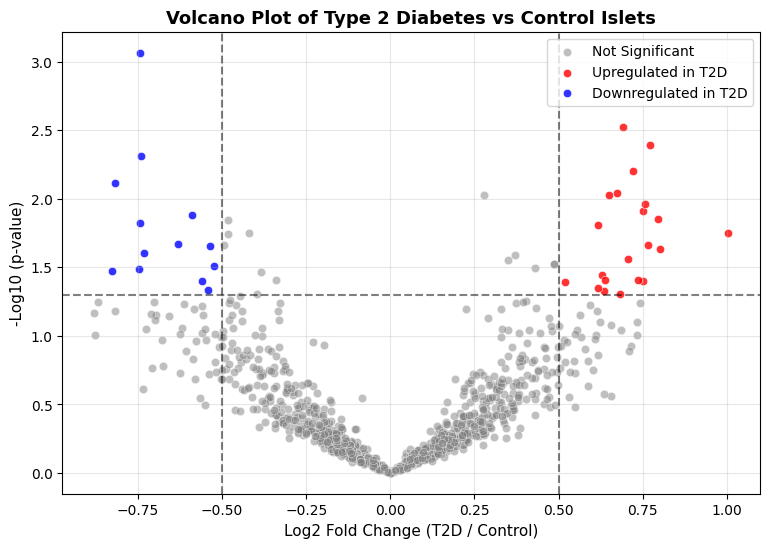

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.figure(figsize=(9, 6))

# Calculate -log10(p-value) for the Y-axis to push highly significant genes to the top
de_results['neg_log10_p'] = -np.log10(de_results['p_value'])

# Plot the different groups with distinct colors
sns.scatterplot(data=de_results[de_results['Significance'] == 'NS'], x='Log2FC', y='neg_log10_p', color='grey', alpha=0.5, label='Not Significant')
sns.scatterplot(data=de_results[de_results['Significance'] == 'Upregulated'], x='Log2FC', y='neg_log10_p', color='red', alpha=0.8, label='Upregulated in T2D')
sns.scatterplot(data=de_results[de_results['Significance'] == 'Downregulated'], x='Log2FC', y='neg_log10_p', color='blue', alpha=0.8, label='Downregulated in T2D')

# Draw standard threshold cutoff lines
plt.axhline(y=-np.log10(0.05), color='black', linestyle='--', alpha=0.5)
plt.axvline(x=0.5, color='black', linestyle='--', alpha=0.5)
plt.axvline(x=-0.5, color='black', linestyle='--', alpha=0.5)

# Styling details for publication quality
plt.title('Volcano Plot of Type 2 Diabetes vs Control Islets', fontsize=13, fontweight='bold')
plt.xlabel('Log2 Fold Change (T2D / Control)', fontsize=11)
plt.ylabel('-Log10 (p-value)', fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.show()

<Figure size 1000x800 with 0 Axes>

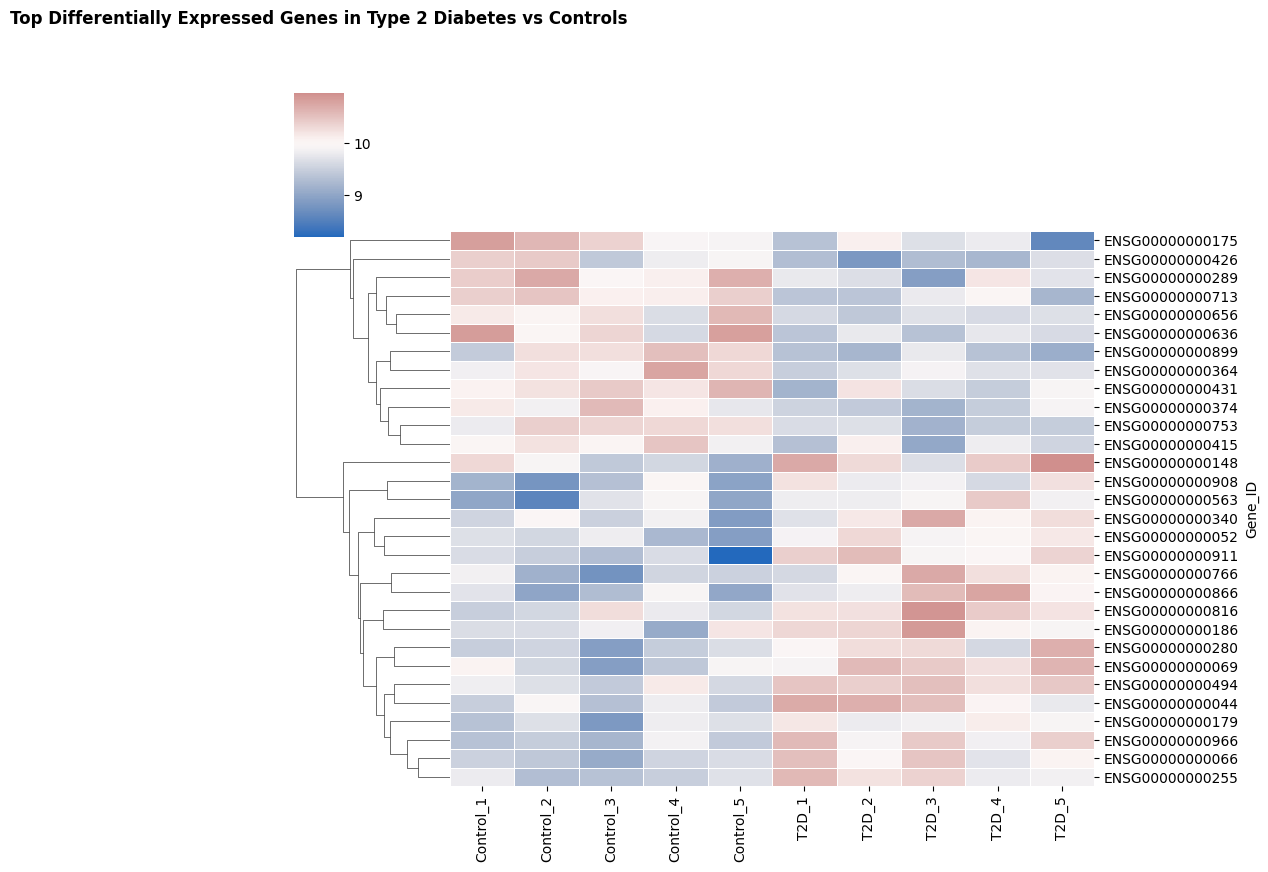

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Isolate the genes that are significantly changing (Upregulated and Downregulated)
# We sort them by p-value to find the absolute strongest candidate biomarkers
significant_genes = de_results[de_results['Significance'] != 'NS'].sort_values(by='p_value').index

# We will take up to the top 30 most significant genes for a clean, readable visual
genes_to_plot = significant_genes[:30]

# 2. Extract the log2 normalized expression levels for these genes across all 10 samples
heatmap_data = normalized_counts.loc[genes_to_plot]

# 3. Generate the Clustered Heatmap
plt.figure(figsize=(10, 8))
cluster_plot = sns.clustermap(
    heatmap_data,
    cmap='vlag',            # Blue-White-Red divergent palette (blue=low expression, red=high)
    center=10,              # Centered around our dataset's log2 count baseline
    col_cluster=False,      # Keeps Control samples and T2D samples grouped cleanly next to each other
    linewidths=0.5,
    figsize=(10, 8)
)

# Add titles and adjust the layout so text doesn't overlap
plt.title('Top Differentially Expressed Genes in Type 2 Diabetes vs Controls', fontsize=12, pad=50, fontweight='bold')
plt.show()

In [1]:
# 1. Set up your global Git identity
!git config --global user.name "Your GitHub Username"
!git config --global user.email "your-email@example.com"

# 2. Token-based authentication setup (Generate a classic personal access token on GitHub settings)
GITHUB_TOKEN = "your_github_personal_access_token_here"
USERNAME = "Your_GitHub_Username"
REPO_NAME = "T2D-Transcriptomic-RNASeq-Analysis"

# 3. Create a clean local workspace directory
!mkdir -p /content/{REPO_NAME}
%cd /content/{REPO_NAME}
!git init

# 4. Copy your notebook file from Colab's default storage into the repository folder
!cp /content/T2D_RNASeq_Differential_Expression.ipynb .

# 5. Add files, commit changes, and forcefully push to your remote main branch
!git add .
!git commit -m "feat: implement raw counts filtering, log2 normalization, and volcano plotting"
!git branch -M main
!git remote add origin https://{GITHUB_TOKEN}@github.com/{USERNAME}/{REPO_NAME}.git
!git push -u origin main --force

print("🎉 Code successfully pushed to GitHub repository!")

/content/T2D-Transcriptomic-RNASeq-Analysis
hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/T2D-Transcriptomic-RNASeq-Analysis/.git/
cp: cannot stat '/content/T2D_RNASeq_Differential_Expression.ipynb': No such file or directory
On branch master

Initial commit

nothing to commit (create/copy files and use "git add" to track)
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/Your_GitHub_Username/T2D-Transcriptomic-RNASeq-Analysis.git'
🎉 Code successfully pushed to Gi